IMPOR LIBRARY

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator

DATASET

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
SKENARIO = 'RGB'

**PREPROCESSING**

In [ ]:
# data mentah
DATASET_PATH = '/content/drive/MyDrive/skripsi/dataset'

# data hasil (otomatis menyesuaikan skenario)
DEST_PATH = f'/content/drive/MyDrive/skripsi/dataset_processed_{SKENARIO}'

IMG_SIZE = 224

# ==========================================
# 2. FUNGSI PEMROSES (Load -> Resize -> CLAHE -> Save)
# ==========================================
def run_dataset_processing(src_dir, dest_dir, scenario):
    if not os.path.exists(dest_dir):
        os.makedirs(dest_dir)

    # Inisialisasi CLAHE
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

    # Membaca sub-folder (Katarak, Glaukoma, dll)
    for category in os.listdir(src_dir):
        category_path = os.path.join(src_dir, category)
        if not os.path.isdir(category_path): continue

        save_path = os.path.join(dest_dir, category)
        if not os.path.exists(save_path):
            os.makedirs(save_path)

        print(f"\n[INFO] Memproses Kategori: {category} | Skenario: {scenario}")

        # Membaca setiap gambar di dalam sub-folder
        for img_name in tqdm(os.listdir(category_path)):
            img_path = os.path.join(category_path, img_name)

            # --- LOAD ---
            image = cv2.imread(img_path)
            if image is None: continue

            # --- RESIZE (224x224) ---
            img_res = cv2.resize(image, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)

            # --- CLAHE (Sesuai Sakelar) ---
            if scenario == 'RGB':
                b, g, r = cv2.split(img_res)
                g_enhanced = clahe.apply(g) # Isolasi saluran hijau
                final_img = cv2.merge((b, g_enhanced, r))

            elif scenario == 'LAB':
                lab = cv2.cvtColor(img_res, cv2.COLOR_BGR2LAB)
                l, a, b = cv2.split(lab)
                l_enhanced = clahe.apply(l) # Isolasi saluran Luminance
                res = cv2.merge((l_enhanced, a, b))
                final_img = cv2.cvtColor(res, cv2.COLOR_LAB2BGR)

            elif scenario == 'YCBCR':
                ycbcr = cv2.cvtColor(img_res, cv2.COLOR_BGR2YCrCb)
                y, cb, cr = cv2.split(ycbcr)
                y_enhanced = clahe.apply(y) # Isolasi saluran Luma
                res = cv2.merge((y_enhanced, cb, cr))
                final_img = cv2.cvtColor(res, cv2.COLOR_YCrCb2BGR)

            # --- SAVE ---
            cv2.imwrite(os.path.join(save_path, img_name), final_img)

# Eksekusi Proses
run_dataset_processing(DATASET_PATH, DEST_PATH, SKENARIO)
print(f"\n[SUKSES] Dataset {SKENARIO} telah siap di: {DEST_PATH}")


[INFO] Memproses Kategori: cataract | Skenario: YCBCR


100%|██████████| 1038/1038 [00:35<00:00, 28.92it/s]



[INFO] Memproses Kategori: normal | Skenario: YCBCR


100%|██████████| 1074/1074 [00:27<00:00, 38.55it/s]



[INFO] Memproses Kategori: diabetic_retinopathy | Skenario: YCBCR


100%|██████████| 1099/1099 [00:28<00:00, 37.90it/s]



[INFO] Memproses Kategori: glaucoma | Skenario: YCBCR


100%|██████████| 1007/1007 [00:35<00:00, 28.11it/s]


[SUKSES] Dataset YCBCR telah siap di: /content/drive/MyDrive/skripsi/dataset_processed_YCBCR


--- DISTRIBUSI DATASET (RGB) ---
Kelas cataract: 1038 gambar
Kelas diabetic_retinopathy: 1099 gambar
Kelas glaucoma: 1007 gambar
Kelas normal: 1074 gambar

Total Seluruh Data: 4218 gambar


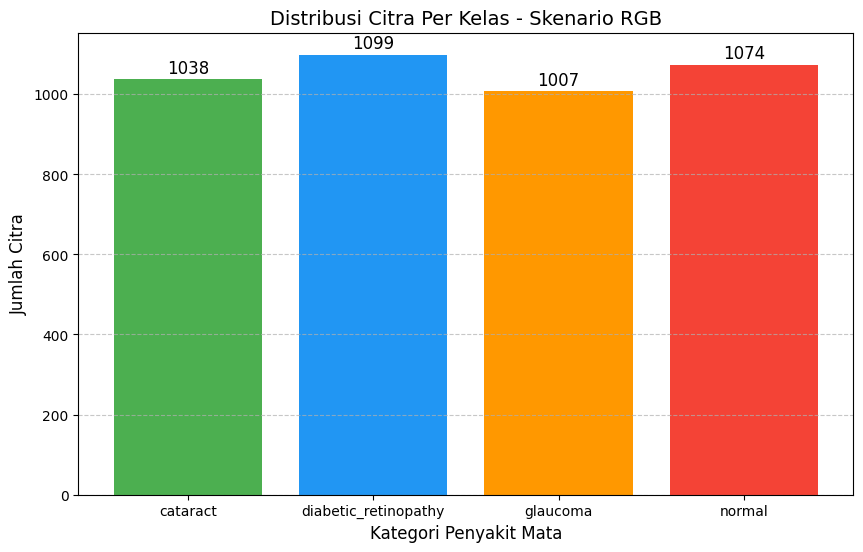

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

def hitung_distribusi_dataset(path):
    # Cek apakah path tersedia
    if not os.path.exists(path):
        print(f"[ERROR] Path tidak ditemukan: {path}")
        return

    data_hitung = []

    # Ambil daftar sub-folder (kelas)
    daftar_kelas = sorted([d for d in os.listdir(path) if os.path.isdir(os.path.join(path, d))])

    print(f"--- DISTRIBUSI DATASET ({SKENARIO}) ---")

    total_seluruh = 0
    for kelas in daftar_kelas:
        kelas_path = os.path.join(path, kelas)
        # Hitung jumlah file (hanya file, bukan sub-folder lain)
        jumlah = len([f for f in os.listdir(kelas_path) if os.path.isfile(os.path.join(kelas_path, f))])
        data_hitung.append({'Kelas': kelas, 'Jumlah': jumlah})
        total_seluruh += jumlah
        print(f"Kelas {kelas}: {jumlah} gambar")

    # 1. Tampilkan dalam bentuk DataFrame (Tabel)
    df = pd.DataFrame(data_hitung)
    print(f"\nTotal Seluruh Data: {total_seluruh} gambar")

    # 2. Visualisasi dengan Bar Chart (Grafik Batang)
    plt.figure(figsize=(10, 6))
    bars = plt.bar(df['Kelas'], df['Jumlah'], color=['#4CAF50', '#2196F3', '#FF9800', '#F44336'])

    # Tambahkan angka di atas setiap batang
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 5, yval, ha='center', va='bottom', fontsize=12)

    plt.title(f"Distribusi Citra Per Kelas - Skenario {SKENARIO}", fontsize=14)
    plt.xlabel("Kategori Penyakit Mata", fontsize=12)
    plt.ylabel("Jumlah Citra", fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

# EKSEKUSI
hitung_distribusi_dataset(DEST_PATH)

**TRAINING**